In [1]:
#instalamos las librerias nuevas en caso el usuario no las tenga

import importlib.util
import subprocess
import sys

librerias = {
    "torch": "torch",
    "matplotlib": "matplotlib",
    "torchvision": "torchvision"
}

for modulo, paquete in librerias.items():
    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])
    else:
        print(f"{paquete} ya está instalado.")


torch ya está instalado.
matplotlib ya está instalado.
torchvision ya está instalado.


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

#fijamos semilla para resultados reproducibles
torch.manual_seed(42)

#definimos los datos del problema xor
x = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

#definimos el perceptron multicapa
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        #primera capa completamente conectada
        self.fc1 = nn.Linear(2, 4)

        #activacion no lineal
        self.act = nn.Tanh()

        #capa de salida
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x


#creamos el modelo
model = MLP()

#definimos perdida y optimizador
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.05
)

#entrenamos el modelo
for epoch in range(2000):

    optimizer.zero_grad()

    logits = model(x)

    loss = criterion(logits, y)

    loss.backward()

    optimizer.step()


#evaluamos el modelo entrenado
with torch.no_grad():

    logits = model(x)

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= 0.5
    ).float()

    accuracy = (
        predictions == y
    ).float().mean()

print("probabilidades:")
print(probabilities)

print("\npredicciones:")
print(predictions)

print(
    "\nexactitud:",
    accuracy.item() * 100,
    "%"
)

probabilidades:
tensor([[3.2537e-06],
        [9.9975e-01],
        [9.9975e-01],
        [4.1199e-04]])

predicciones:
tensor([[0.],
        [1.],
        [1.],
        [0.]])

exactitud: 100.0 %


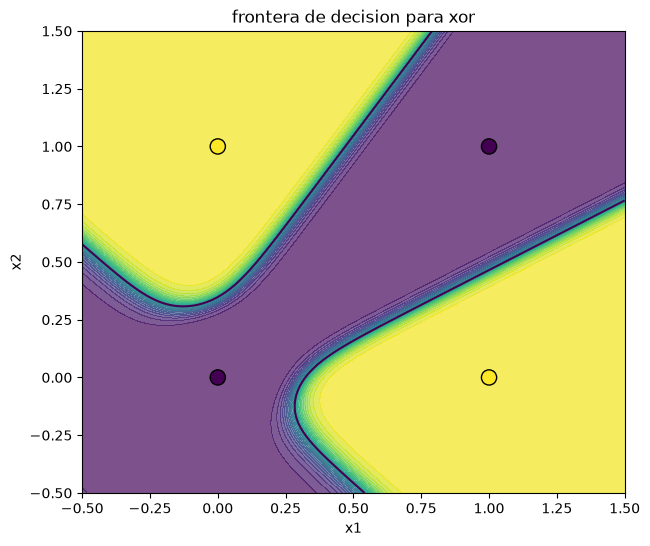

In [3]:
#creamos valores para ambos ejes
x1 = torch.linspace(-0.5, 1.5, 200)
x2 = torch.linspace(-0.5, 1.5, 200)

#creamos una malla sobre el plano
xx1, xx2 = torch.meshgrid(
    x1,
    x2,
    indexing="xy"
)

#convertimos la malla en pares
grid = torch.stack(
    [
        xx1.reshape(-1),
        xx2.reshape(-1)
    ],
    dim=1
)

#calculamos probabilidades sobre toda la malla
with torch.no_grad():

    grid_logits = model(grid)

    grid_probabilities = torch.sigmoid(
        grid_logits
    )

#recuperamos la forma original
zz = grid_probabilities.reshape(
    xx1.shape
)

#graficamos la frontera aprendida
plt.figure(figsize=(7, 6))

plt.contourf(
    xx1.numpy(),
    xx2.numpy(),
    zz.numpy(),
    levels=30,
    alpha=0.7
)

#marcamos la frontera de decision
plt.contour(
    xx1.numpy(),
    xx2.numpy(),
    zz.numpy(),
    levels=[0.5]
)

#graficamos los puntos xor
plt.scatter(
    x[:, 0].numpy(),
    x[:, 1].numpy(),
    c=y.squeeze().numpy(),
    s=120,
    edgecolors="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("frontera de decision para xor")

plt.show()

In [4]:
#definimos el modelo sin activacion
class MLPLineal(nn.Module):
    def __init__(self):
        super().__init__()

        #primera capa lineal
        self.fc1 = nn.Linear(2, 4)

        #segunda capa lineal
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x


#creamos el modelo lineal
model_lineal = MLPLineal()

#definimos perdida y optimizador
criterion_lineal = nn.BCEWithLogitsLoss()

optimizer_lineal = torch.optim.Adam(
    model_lineal.parameters(),
    lr=0.05
)

#entrenamos bajo las mismas condiciones
for epoch in range(2000):

    optimizer_lineal.zero_grad()

    logits = model_lineal(x)

    loss = criterion_lineal(
        logits,
        y
    )

    loss.backward()

    optimizer_lineal.step()


#evaluamos el modelo lineal
with torch.no_grad():

    logits = model_lineal(x)

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= 0.5
    ).float()

    accuracy = (
        predictions == y
    ).float().mean()


print("probabilidades:")
print(probabilities)

print("\npredicciones:")
print(predictions)

print(
    "\nexactitud:",
    accuracy.item() * 100,
    "%"
)

probabilidades:
tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000]])

predicciones:
tensor([[1.],
        [1.],
        [1.],
        [1.]])

exactitud: 50.0 %


Sin activacion las capas forman una transformacion afin, por eso mantienen una frontera de decision lineal. XOR necesita una frontera de decision no lineal.

In [5]:
#definimos la red solicitada
class RedMulticapa(nn.Module):
    def __init__(self):
        super().__init__()

        #primera capa oculta
        self.fc1 = nn.Linear(3, 4)

        #segunda capa oculta
        self.fc2 = nn.Linear(4, 4)

        #capa de salida
        self.fc3 = nn.Linear(4, 2)

        #activacion para capas ocultas
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x


#creamos la red
red = RedMulticapa()

#contamos todos los parametros
total_parametros = sum(
    parametro.numel()
    for parametro in red.parameters()
)

print(red)

print(
    "\ntotal de parametros:",
    total_parametros
)

RedMulticapa(
  (fc1): Linear(in_features=3, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

total de parametros: 46


In [6]:
#recorremos todos los parametros del modelo
for nombre, parametro in red.named_parameters():

    print(
        nombre,
        "->",
        tuple(parametro.shape)
    )

fc1.weight -> (4, 3)
fc1.bias -> (4,)
fc2.weight -> (4, 4)
fc2.bias -> (4,)
fc3.weight -> (2, 4)
fc3.bias -> (2,)


In [7]:
#creamos valores entre menos cinco y cinco
z = torch.linspace(
    -5,
    5,
    200,
    requires_grad=True
)

#calculamos la funcion sigmoide
sigmoid = torch.sigmoid(z)

#calculamos la funcion tanh
tanh = torch.tanh(z)

#calculamos la funcion relu
relu = torch.relu(z)

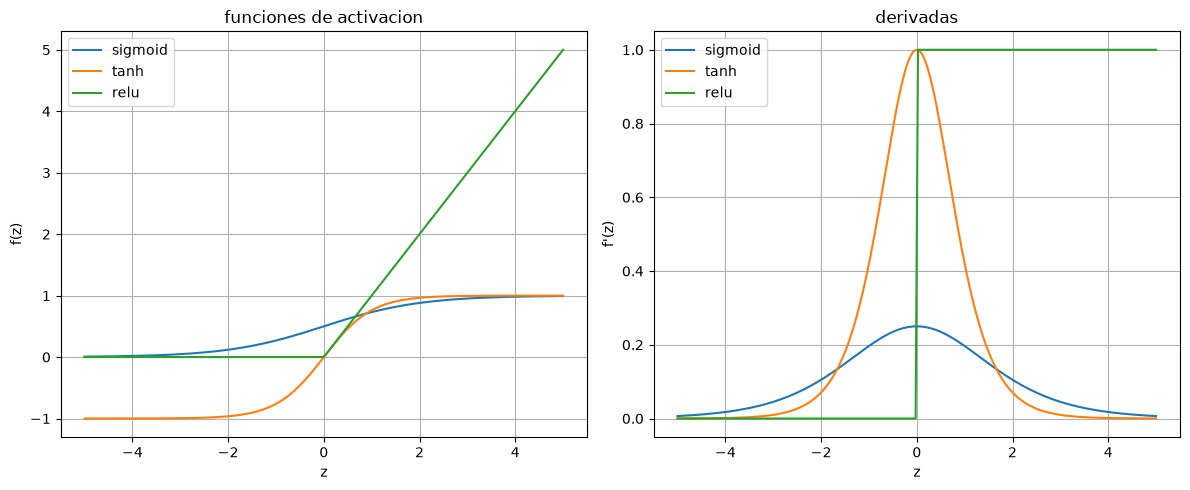

In [8]:
#calculamos la derivada de sigmoide
grad_sigmoid = torch.autograd.grad(
    sigmoid,
    z,
    grad_outputs=torch.ones_like(sigmoid),
    retain_graph=True
)[0]

#calculamos la derivada de tanh
grad_tanh = torch.autograd.grad(
    tanh,
    z,
    grad_outputs=torch.ones_like(tanh),
    retain_graph=True
)[0]

#calculamos la derivada de relu
grad_relu = torch.autograd.grad(
    relu,
    z,
    grad_outputs=torch.ones_like(relu)
)[0]

#convertimos tensores para graficar
z_np = z.detach().numpy()

sigmoid_np = sigmoid.detach().numpy()
tanh_np = tanh.detach().numpy()
relu_np = relu.detach().numpy()

grad_sigmoid_np = grad_sigmoid.detach().numpy()
grad_tanh_np = grad_tanh.detach().numpy()
grad_relu_np = grad_relu.detach().numpy()

#creamos figura con dos paneles
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

#graficamos las funciones
axes[0].plot(
    z_np,
    sigmoid_np,
    label="sigmoid"
)

axes[0].plot(
    z_np,
    tanh_np,
    label="tanh"
)

axes[0].plot(
    z_np,
    relu_np,
    label="relu"
)

axes[0].set_title(
    "funciones de activacion"
)

axes[0].set_xlabel("z")
axes[0].set_ylabel("f(z)")
axes[0].legend()
axes[0].grid()

#graficamos las derivadas
axes[1].plot(
    z_np,
    grad_sigmoid_np,
    label="sigmoid"
)

axes[1].plot(
    z_np,
    grad_tanh_np,
    label="tanh"
)

axes[1].plot(
    z_np,
    grad_relu_np,
    label="relu"
)

axes[1].set_title(
    "derivadas"
)

axes[1].set_xlabel("z")
axes[1].set_ylabel("f'(z)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

sigmoide pierde gradiente en valores muy negativos, tambien pierde gradiente en valores muy positivos, su derivada se acerca a cero. tanh pierde gradiente lejos de cero su derivada tambien se acerca a cero. relu mantiene gradiente constante para valores positivos esto facilita entrenar redes profundas por eso suele usarse en capas ocultas

In [9]:
import numpy as np

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix

#fijamos semilla para resultados reproducibles
torch.manual_seed(42)

#cargamos el conjunto iris
iris = load_iris()

#separamos entradas y etiquetas
X = iris.data.astype(np.float32)
y = iris.target.astype(np.int64)

#dividimos entrenamiento y validacion
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#calculamos estadisticas solo con entrenamiento
media = X_train.mean(axis=0)
desviacion = X_train.std(axis=0)

#estandarizamos el conjunto de entrenamiento
X_train = (
    X_train - media
) / desviacion

#usamos las mismas estadisticas en validacion
X_val = (
    X_val - media
) / desviacion

#convertimos los datos a tensores
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val = torch.tensor(
    y_val,
    dtype=torch.long
)

print("entrenamiento:", X_train.shape)
print("validacion:", X_val.shape)

entrenamiento: torch.Size([120, 4])
validacion: torch.Size([30, 4])


In [10]:
#definimos la red para clasificar iris
class IrisMLP(nn.Module):
    def __init__(self):
        super().__init__()

        #capa oculta con ocho neuronas
        self.fc1 = nn.Linear(4, 8)

        #activacion no lineal
        self.relu = nn.ReLU()

        #salida con tres clases
        self.fc2 = nn.Linear(8, 3)

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


#creamos un modelo inicial
modelo = IrisMLP()

#contamos todos los parametros
total_parametros = sum(
    parametro.numel()
    for parametro in modelo.parameters()
)

print(modelo)

print(
    "\ntotal de parametros:",
    total_parametros
)

IrisMLP(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)

total de parametros: 67


In [11]:
#definimos entrenamiento usando sgd
def entrenar_sgd(tasa, epocas=1000):

    #reiniciamos semilla para comparar justamente
    torch.manual_seed(42)

    #creamos un modelo nuevo
    modelo = IrisMLP()

    #definimos la funcion de perdida
    criterion = nn.CrossEntropyLoss()

    #definimos el optimizador sgd
    optimizer = torch.optim.SGD(
        modelo.parameters(),
        lr=tasa
    )

    #guardamos la perdida por epoca
    perdidas = []

    #entrenamos durante varias epocas
    for epoch in range(epocas):

        #limpiamos gradientes anteriores
        optimizer.zero_grad()

        #hacemos el paso forward
        logits = modelo(X_train)

        #calculamos la perdida
        loss = criterion(
            logits,
            y_train
        )

        #calculamos los gradientes
        loss.backward()

        #actualizamos los parametros
        optimizer.step()

        #guardamos la perdida actual
        perdidas.append(
            loss.item()
        )

    return modelo, perdidas

#crossentropyloss recibe logits directamente

#internamente combina logsoftmax y nllloss

#por eso no agregamos softmax al modelo

#aplicar softmax antes seria redundante

#tambien puede reducir la estabilidad numerica

tasa: 0.001 perdida final: 0.8987711668014526
tasa: 0.1 perdida final: 0.04664003849029541
tasa: 10.0 perdida final: 0.7823697328567505


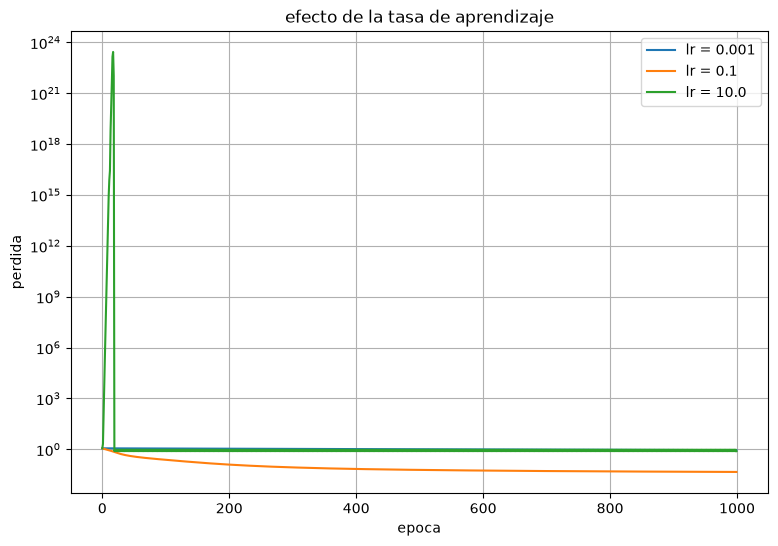

In [12]:
#definimos las tasas de aprendizaje
tasas = [
    0.001,
    0.1,
    10.0
]

#guardamos modelos y perdidas
modelos_sgd = {}
perdidas_sgd = {}

#entrenamos con cada tasa
for tasa in tasas:

    modelo_actual, perdidas = entrenar_sgd(
        tasa
    )

    modelos_sgd[tasa] = modelo_actual
    perdidas_sgd[tasa] = perdidas

    print(
        "tasa:",
        tasa,
        "perdida final:",
        perdidas[-1]
    )


#graficamos las tres curvas
plt.figure(figsize=(9, 6))

for tasa in tasas:

    plt.plot(
        perdidas_sgd[tasa],
        label=f"lr = {tasa}"
    )

#usamos escala logaritmica
plt.yscale("log")

plt.xlabel("epoca")
plt.ylabel("perdida")

plt.title(
    "efecto de la tasa de aprendizaje"
)

plt.legend()
plt.grid()

plt.show()

#0.001 aprende demasiado lento

#0.1 converge de forma estable

#10 produce cambios demasiado grandes

#su perdida presenta comportamiento inestable

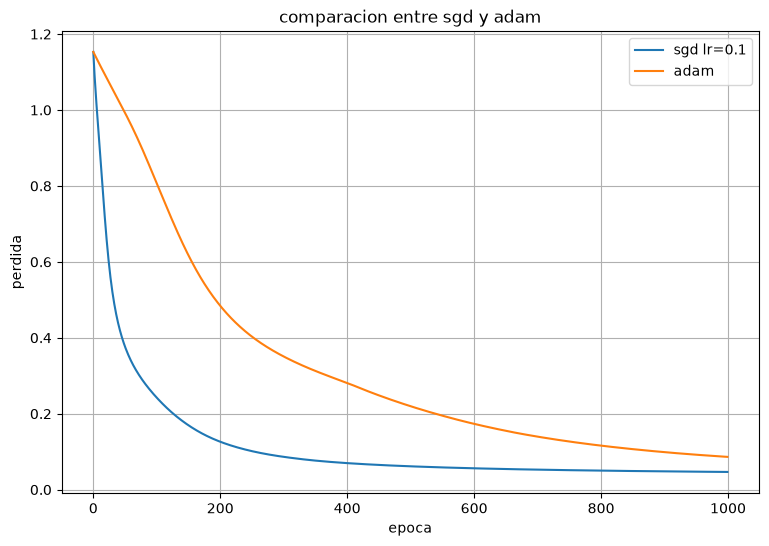

In [13]:
#definimos entrenamiento usando adam
def entrenar_adam(epocas=1000):

    #reiniciamos semilla para comparar justamente
    torch.manual_seed(42)

    #creamos un modelo nuevo
    modelo = IrisMLP()

    #definimos la funcion de perdida
    criterion = nn.CrossEntropyLoss()

    #adam usa su tasa por defecto
    optimizer = torch.optim.Adam(
        modelo.parameters()
    )

    #guardamos la perdida por epoca
    perdidas = []

    #entrenamos durante varias epocas
    for epoch in range(epocas):

        #limpiamos gradientes anteriores
        optimizer.zero_grad()

        #hacemos el paso forward
        logits = modelo(X_train)

        #calculamos la perdida
        loss = criterion(
            logits,
            y_train
        )

        #calculamos los gradientes
        loss.backward()

        #actualizamos los parametros
        optimizer.step()

        #guardamos la perdida actual
        perdidas.append(
            loss.item()
        )

    return modelo, perdidas


#entrenamos usando adam
modelo_adam, perdidas_adam = entrenar_adam()

#seleccionamos la mejor tasa de sgd
mejor_tasa = min(
    tasas,
    key=lambda tasa: perdidas_sgd[tasa][-1]
)

#graficamos ambas curvas
plt.figure(figsize=(9, 6))

plt.plot(
    perdidas_sgd[mejor_tasa],
    label=f"sgd lr={mejor_tasa}"
)

plt.plot(
    perdidas_adam,
    label="adam"
)

plt.xlabel("epoca")
plt.ylabel("perdida")

plt.title(
    "comparacion entre sgd y adam"
)

plt.legend()
plt.grid()

plt.show()

In [14]:
#definimos funcion para evaluar modelos
def evaluar_modelo(modelo):

    #activamos modo de evaluacion
    modelo.eval()

    #desactivamos calculo de gradientes
    with torch.no_grad():

        #calculamos logits de validacion
        logits = modelo(X_val)

        #seleccionamos la clase mayor
        predicciones = torch.argmax(
            logits,
            dim=1
        )

        #calculamos la exactitud
        exactitud = (
            predicciones == y_val
        ).float().mean()

    return exactitud.item(), predicciones


#evaluamos el mejor modelo sgd
modelo_sgd = modelos_sgd[mejor_tasa]

acc_sgd, pred_sgd = evaluar_modelo(
    modelo_sgd
)

#evaluamos el modelo adam
acc_adam, pred_adam = evaluar_modelo(
    modelo_adam
)

print(
    "exactitud sgd:",
    acc_sgd * 100,
    "%"
)

print(
    "exactitud adam:",
    acc_adam * 100,
    "%"
)


#seleccionamos el mejor modelo
if acc_sgd >= acc_adam:

    mejor_modelo = modelo_sgd
    mejor_nombre = "sgd"

else:

    mejor_modelo = modelo_adam
    mejor_nombre = "adam"


#evaluamos nuevamente el mejor modelo
mejor_modelo.eval()

with torch.no_grad():

    logits = mejor_modelo(X_val)

    predicciones = torch.argmax(
        logits,
        dim=1
    )

    exactitud = (
        predicciones == y_val
    ).float().mean()


#calculamos la matriz de confusion
matriz = confusion_matrix(
    y_val.numpy(),
    predicciones.numpy()
)

print(
    "\nmejor modelo:",
    mejor_nombre
)

print(
    "exactitud final:",
    exactitud.item() * 100,
    "%"
)

print(
    "\nmatriz de confusion:"
)

print(matriz)


#buscamos el par mas confundido
nombres = iris.target_names

mayor_error = -1
mejor_par = None

for i in range(len(nombres)):

    for j in range(
        i + 1,
        len(nombres)
    ):

        errores = (
            matriz[i, j]
            + matriz[j, i]
        )

        if errores > mayor_error:

            mayor_error = errores
            mejor_par = (
                nombres[i],
                nombres[j]
            )


print(
    "\npar mas confundido:",
    mejor_par
)

exactitud sgd: 96.66666388511658 %
exactitud adam: 96.66666388511658 %

mejor modelo: sgd
exactitud final: 96.66666388511658 %

matriz de confusion:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

par mas confundido: (np.str_('versicolor'), np.str_('virginica'))


In [15]:
import nltk
import random
import pandas as pd

from nltk.corpus import treebank

from torch.nn.utils.rnn import pad_sequence

#descargamos los recursos necesarios
nltk.download(
    "treebank",
    quiet=True
)

nltk.download(
    "universal_tagset",
    quiet=True
)

#fijamos semillas para reproducibilidad
torch.manual_seed(42)
random.seed(42)

#cargamos oraciones etiquetadas
sentencias = treebank.tagged_sents(
    tagset="universal"
)

#convertimos a lista normal
sentencias = list(sentencias)

#mezclamos las oraciones
random.shuffle(sentencias)

#calculamos punto de division
corte = int(
    0.8 * len(sentencias)
)

#dividimos entrenamiento y prueba
train_sents = sentencias[:corte]
test_sents = sentencias[corte:]

#definimos simbolos especiales
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_TAG = "<PAD>"

#creamos vocabulario de palabras
word_to_idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

#agregamos palabras de entrenamiento
for sentencia in train_sents:

    for palabra, etiqueta in sentencia:

        if palabra not in word_to_idx:

            word_to_idx[palabra] = len(
                word_to_idx
            )

#creamos vocabulario de etiquetas
tag_to_idx = {
    PAD_TAG: 0
}

#agregamos etiquetas de entrenamiento
for sentencia in train_sents:

    for palabra, etiqueta in sentencia:

        if etiqueta not in tag_to_idx:

            tag_to_idx[etiqueta] = len(
                tag_to_idx
            )

#creamos conversion inversa
idx_to_tag = {
    indice: etiqueta
    for etiqueta, indice
    in tag_to_idx.items()
}

#guardamos indices especiales
PAD_IDX = word_to_idx[PAD_TOKEN]
UNK_IDX = word_to_idx[UNK_TOKEN]
TAG_PAD_IDX = tag_to_idx[PAD_TAG]

print(
    "oraciones entrenamiento:",
    len(train_sents)
)

print(
    "oraciones prueba:",
    len(test_sents)
)

print(
    "palabras:",
    len(word_to_idx)
)

print(
    "etiquetas:",
    len(tag_to_idx)
)

print(
    "\netiquetas:",
    tag_to_idx
)

oraciones entrenamiento: 3131
oraciones prueba: 783
palabras: 10985
etiquetas: 13

etiquetas: {'<PAD>': 0, 'DET': 1, 'NOUN': 2, 'VERB': 3, 'ADP': 4, 'PRON': 5, '.': 6, 'NUM': 7, 'X': 8, 'CONJ': 9, 'PRT': 10, 'ADJ': 11, 'ADV': 12}


In [16]:
#convertimos una oracion a indices
def codificar_sentencia(sentencia):

    palabras = []

    etiquetas = []

    for palabra, etiqueta in sentencia:

        indice_palabra = word_to_idx.get(
            palabra,
            UNK_IDX
        )

        palabras.append(
            indice_palabra
        )

        etiquetas.append(
            tag_to_idx[etiqueta]
        )

    return (
        torch.tensor(
            palabras,
            dtype=torch.long
        ),
        torch.tensor(
            etiquetas,
            dtype=torch.long
        )
    )


#codificamos conjuntos completos
train_data = [
    codificar_sentencia(sentencia)
    for sentencia in train_sents
]

test_data = [
    codificar_sentencia(sentencia)
    for sentencia in test_sents
]


#creamos batches con relleno
def crear_batches(
    datos,
    batch_size=32,
    shuffle=True
):

    indices = list(
        range(len(datos))
    )

    if shuffle:

        random.shuffle(indices)

    for inicio in range(
        0,
        len(indices),
        batch_size
    ):

        batch_indices = indices[
            inicio:inicio + batch_size
        ]

        palabras = [
            datos[i][0]
            for i in batch_indices
        ]

        etiquetas = [
            datos[i][1]
            for i in batch_indices
        ]

        palabras = pad_sequence(
            palabras,
            batch_first=True,
            padding_value=PAD_IDX
        )

        etiquetas = pad_sequence(
            etiquetas,
            batch_first=True,
            padding_value=TAG_PAD_IDX
        )

        yield palabras, etiquetas


#definimos modelo basado en lstm
class LSTMTagger(nn.Module):

    def __init__(
        self,
        vocab_size,
        tag_size,
        embedding_dim=64,
        hidden_dim=64
    ):

        super().__init__()

        #convertimos palabras en vectores
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_IDX
        )

        #procesamos la secuencia completa
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        #producimos una etiqueta por token
        self.linear = nn.Linear(
            hidden_dim,
            tag_size
        )

    def forward(self, x):

        x = self.embedding(x)

        x, _ = self.lstm(x)

        x = self.linear(x)

        return x


#creamos el modelo lstm
torch.manual_seed(42)

model_lstm = LSTMTagger(
    len(word_to_idx),
    len(tag_to_idx)
)

#definimos perdida ignorando relleno
criterion = nn.CrossEntropyLoss(
    ignore_index=TAG_PAD_IDX
)

print(model_lstm)

LSTMTagger(
  (embedding): Embedding(10985, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=13, bias=True)
)


In [17]:
#definimos ciclo de entrenamiento
def entrenar_modelo(
    modelo,
    epocas=5
):

    #usamos adam para optimizar
    optimizer = torch.optim.Adam(
        modelo.parameters()
    )

    #guardamos perdidas por epoca
    historial = []

    for epoch in range(epocas):

        #activamos modo entrenamiento
        modelo.train()

        perdida_total = 0

        batches = 0

        for palabras, etiquetas in crear_batches(
            train_data
        ):

            #limpiamos gradientes anteriores
            optimizer.zero_grad()

            #hacemos el paso forward
            logits = modelo(palabras)

            #adaptamos dimensiones para la perdida
            logits_flat = logits.reshape(
                -1,
                logits.shape[-1]
            )

            etiquetas_flat = etiquetas.reshape(
                -1
            )

            #calculamos la perdida
            loss = criterion(
                logits_flat,
                etiquetas_flat
            )

            #calculamos gradientes
            loss.backward()

            #actualizamos los parametros
            optimizer.step()

            perdida_total += loss.item()
            batches += 1

        perdida_promedio = (
            perdida_total / batches
        )

        historial.append(
            perdida_promedio
        )

        print(
            "epoca:",
            epoch + 1,
            "perdida:",
            round(
                perdida_promedio,
                4
            )
        )

    return historial


#definimos evaluacion por token
def evaluar_modelo(modelo):

    #activamos modo evaluacion
    modelo.eval()

    correctos = 0
    total = 0

    #desactivamos gradientes
    with torch.no_grad():

        for palabras, etiquetas in crear_batches(
            test_data,
            shuffle=False
        ):

            logits = modelo(
                palabras
            )

            predicciones = torch.argmax(
                logits,
                dim=2
            )

            #ignoramos posiciones de relleno
            mascara = (
                etiquetas != TAG_PAD_IDX
            )

            correctos += (
                predicciones[mascara]
                == etiquetas[mascara]
            ).sum().item()

            total += mascara.sum().item()

    return correctos / total


#entrenamos el modelo lstm
historial_lstm = entrenar_modelo(
    model_lstm,
    epocas=5
)

#calculamos exactitud por token
accuracy_lstm = evaluar_modelo(
    model_lstm
)

print(
    "\nexactitud lstm:",
    round(
        accuracy_lstm * 100,
        2
    ),
    "%"
)

epoca: 1 perdida: 1.9233
epoca: 2 perdida: 1.0352
epoca: 3 perdida: 0.7145
epoca: 4 perdida: 0.5512
epoca: 5 perdida: 0.4447

exactitud lstm: 87.3 %


In [18]:
#definimos modelo basado en rnn
class RNNTagger(nn.Module):

    def __init__(
        self,
        vocab_size,
        tag_size,
        embedding_dim=64,
        hidden_dim=64
    ):

        super().__init__()

        #convertimos palabras en vectores
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_IDX
        )

        #procesamos la secuencia con rnn
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        #producimos una etiqueta por token
        self.linear = nn.Linear(
            hidden_dim,
            tag_size
        )

    def forward(self, x):

        x = self.embedding(x)

        x, _ = self.rnn(x)

        x = self.linear(x)

        return x


#reiniciamos semilla para comparar justamente
torch.manual_seed(42)
random.seed(42)

#creamos el modelo rnn
model_rnn = RNNTagger(
    len(word_to_idx),
    len(tag_to_idx)
)

#entrenamos el modelo rnn
historial_rnn = entrenar_modelo(
    model_rnn,
    epocas=5
)

#calculamos exactitud por token
accuracy_rnn = evaluar_modelo(
    model_rnn
)

#creamos tabla comparativa
tabla_modelos = pd.DataFrame({
    "modelo": [
        "LSTM",
        "RNN"
    ],
    "exactitud": [
        accuracy_lstm,
        accuracy_rnn
    ]
})

#mostramos porcentajes
tabla_modelos["exactitud"] = (
    tabla_modelos["exactitud"] * 100
)

tabla_modelos

epoca: 1 perdida: 1.6301
epoca: 2 perdida: 0.9345
epoca: 3 perdida: 0.6931
epoca: 4 perdida: 0.5527
epoca: 5 perdida: 0.4572


,modelo,exactitud
0,LSTM,87.295853
1,RNN,85.769524


In [19]:
#seleccionamos el modelo con mayor exactitud
if accuracy_lstm >= accuracy_rnn:

    mejor_modelo = model_lstm
    mejor_nombre = "LSTM"

else:

    mejor_modelo = model_rnn
    mejor_nombre = "RNN"


#definimos funcion para etiquetar palabras
def etiquetar_oracion(
    modelo,
    palabras
):

    #convertimos palabras en indices
    indices = [
        word_to_idx.get(
            palabra,
            UNK_IDX
        )
        for palabra in palabras
    ]

    entrada = torch.tensor(
        indices,
        dtype=torch.long
    ).unsqueeze(0)

    #activamos modo evaluacion
    modelo.eval()

    #desactivamos gradientes
    with torch.no_grad():

        logits = modelo(
            entrada
        )

        predicciones = torch.argmax(
            logits,
            dim=2
        ).squeeze(0)

    etiquetas = [
        idx_to_tag[indice.item()]
        for indice in predicciones
    ]

    return list(
        zip(
            palabras,
            etiquetas
        )
    )


#creamos oraciones con palabras ambiguas
oraciones_ambiguas = [
    [
        "I",
        "will",
        "book",
        "the",
        "room",
        "."
    ],
    [
        "The",
        "book",
        "is",
        "on",
        "the",
        "table",
        "."
    ],
    [
        "They",
        "run",
        "every",
        "morning",
        "."
    ],
    [
        "The",
        "run",
        "was",
        "difficult",
        "."
    ]
]

print(
    "mejor modelo:",
    mejor_nombre
)

#etiquetamos cada oracion
for palabras in oraciones_ambiguas:

    resultado = etiquetar_oracion(
        mejor_modelo,
        palabras
    )

    print()

    for palabra, etiqueta in resultado:

        print(
            palabra,
            "->",
            etiqueta
        )

mejor modelo: LSTM

I -> PRON
will -> VERB
book -> VERB
the -> DET
room -> NOUN
. -> .

The -> DET
book -> NOUN
is -> VERB
on -> ADP
the -> DET
table -> NOUN
. -> .

They -> PRON
run -> VERB
every -> DET
morning -> NOUN
. -> .

The -> DET
run -> NOUN
was -> VERB
difficult -> NOUN
. -> .


In [20]:
#descargamos el tagger de nltk
nltk.download(
    "averaged_perceptron_tagger_eng",
    quiet=True
)

#contamos predicciones correctas
correctos_nltk = 0
total_nltk = 0

#evaluamos las mismas oraciones de prueba
for sentencia in test_sents:

    #extraemos palabras originales
    palabras = [
        palabra
        for palabra, etiqueta
        in sentencia
    ]

    #extraemos etiquetas reales
    etiquetas_reales = [
        etiqueta
        for palabra, etiqueta
        in sentencia
    ]

    #obtenemos etiquetas universales
    predicciones_nltk = nltk.pos_tag(
        palabras,
        tagset="universal"
    )

    etiquetas_nltk = [
        etiqueta
        for palabra, etiqueta
        in predicciones_nltk
    ]

    #comparamos token por token
    for real, predicha in zip(
        etiquetas_reales,
        etiquetas_nltk
    ):

        if real == predicha:

            correctos_nltk += 1

        total_nltk += 1


#calculamos exactitud de nltk
accuracy_nltk = (
    correctos_nltk / total_nltk
)

#creamos tabla final
tabla_final = pd.DataFrame({
    "modelo": [
        "LSTM",
        "RNN",
        "NLTK"
    ],
    "exactitud": [
        accuracy_lstm * 100,
        accuracy_rnn * 100,
        accuracy_nltk * 100
    ]
})

tabla_final

,modelo,exactitud
0,LSTM,87.295853
1,RNN,85.769524
2,NLTK,90.409565


El modelo LSTM obtuvo una exactitud de 87.30% por token, mientras que el tagger de spaCy utilizado en el Laboratorio 6 obtuvo 97.06% de coincidencia con las etiquetas manuales. La diferencia puede atribuirse principalmente al tamaño y calidad de los datos de entrenamiento, ya que nuestro modelo fue entrenado únicamente con una parte del corpus Treebank. Además, los embeddings del LSTM se aprendieron desde cero durante pocas épocas, mientras que spaCy utiliza un modelo previamente entrenado con más datos y una representación lingüística más completa. La arquitectura también influye: aunque el LSTM puede aprovechar el contexto de la oración y resolver palabras ambiguas, nuestro modelo es relativamente sencillo y cuenta con menos información y entrenamiento que el tagger de spaCy. Por estas razones, es razonable que spaCy obtenga una exactitud mayor.